# 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


# **Import the libraries** 

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor,early_stopping, log_evaluation
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

# **Load all the given dataset**

In [3]:
cinepos_theaters = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv")
booknow_theaters = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv")
movie_theater_map = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv")
cinepos_booking = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv")
booknow_booking = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv")
booknow_visits = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")  # contains audience_count (target)
date_info = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv")


# **Understanding each data frame given**

In [4]:
print("The content in dataframe cinepos_theaters is: \n", cinepos_theaters.head())
print("The content in dataframe booknow_theaters is: \n", booknow_theaters.head())
print("The content in dataframe movie_theater_map is : \n",movie_theater_map.head())
print("The content in dataframe cinepos_booking is: \n",cinepos_booking.head())
print("The content in dataframe booknow_booking is: \n",booknow_booking.head())
print("The content in dataframe booknow_visits is: \n",booknow_visits.head())
print("The content in dataframe date_info is: \n",date_info.head())

The content in dataframe cinepos_theaters is: 
   cine_theater_id theater_type theater_area   latitude  longitude
0   cinePOS_05466        Other     Area_104  22.619233  78.113017
1   cinePOS_08708        Other     Area_104  22.619233  78.113017
2   cinePOS_00753        Other     Area_104  22.619233  78.113017
3   cinePOS_05776        Other     Area_104  22.619233  78.113017
4   cinePOS_07536        Other     Area_104  23.004410  79.934515
The content in dataframe booknow_theaters is: 
   book_theater_id theater_type theater_area   latitude  longitude
0      book_00093        Drama     Area_001  22.619233  78.113017
1      book_00078        Drama     Area_001  22.619233  78.113017
2      book_00291        Drama     Area_001  22.619233  78.113017
3      book_00258        Drama     Area_001  22.619233  78.113017
4      book_00212        Drama     Area_002  23.004410  79.934515
The content in dataframe movie_theater_map is : 
   book_theater_id cine_theater_id
0      book_00509   cinePOS_

# **Cleaning the dataframes**

In [5]:
def null_values(df):
    ans = ((df.isna().sum()/df.shape[0])*100)
    return ans
     

na_vals_1 = null_values(cinepos_theaters)
na_vals_2 = null_values(booknow_theaters)
na_vals_3 = null_values(movie_theater_map)
na_vals_4 = null_values(cinepos_booking)
na_vals_5 = null_values(booknow_booking)
na_vals_6 = null_values(booknow_visits)
na_vals_7 = null_values(date_info)


print("The Null Values in dataframe cinepos_theaters are: \n", na_vals_1)
print("The Null Values in dataframe booknow_theaters are: \n", na_vals_2)
print("The Null Values in dataframe movie_theater_map are : \n",na_vals_3)
print("The Null Values in dataframe cinepos_booking are: \n",na_vals_4)
print("The Null Values in dataframe booknow_booking are: \n",na_vals_5)
print("The Null Values in dataframe booknow_visits are: \n",na_vals_6)
print("The Null Values in dataframe date_info are: \n",na_vals_7)

The Null Values in dataframe cinepos_theaters are: 
 cine_theater_id     0.000000
theater_type        0.000000
theater_area        0.000000
latitude           82.324094
longitude          82.324094
dtype: float64
The Null Values in dataframe booknow_theaters are: 
 book_theater_id    62.12304
theater_type        0.00000
theater_area        0.00000
latitude            0.00000
longitude           0.00000
dtype: float64
The Null Values in dataframe movie_theater_map are : 
 book_theater_id    0.0
cine_theater_id    0.0
dtype: float64
The Null Values in dataframe cinepos_booking are: 
 cine_theater_id     0.0
show_datetime       0.0
booking_datetime    0.0
tickets_sold        0.0
dtype: float64
The Null Values in dataframe booknow_booking are: 
 book_theater_id     0.0
show_datetime       0.0
booking_datetime    0.0
tickets_booked      0.0
dtype: float64
The Null Values in dataframe booknow_visits are: 
 book_theater_id    0.0
show_date          0.0
audience_count     0.0
dtype: float64
Th

In [6]:
# Drop rows in booknow_theater which are missing

booknow_theaters.dropna(subset =["book_theater_id"], inplace=True)

In [7]:
len(booknow_theaters)

314

In [8]:
# Drop columns " latitude",'longitude'in cinepos_theaters which have many null values

cinepos_theaters = cinepos_theaters.drop(["latitude",'longitude'] , axis=1)


(cinepos_theaters.isna().sum()/cinepos_theaters.shape[0])*100

cine_theater_id    0.0
theater_type       0.0
theater_area       0.0
dtype: float64

# **Milestone 1**

In [9]:
# What is the shape of the dataset named booknow_booking?


# booknow_booking.shape

In [10]:
# How many columns are of type Object in the dataset named cinePOS_theaters?


# cinepos_theaters.select_dtypes(include='object').columns

In [11]:
# Which of the following theater types is the most frequent in the dataset named booknow_theaters?
# Action ,Comedy,Drama,Other

# booknow_theaters['theater_type'].value_counts()

In [12]:
# How many distinct theaters are present in the dataset named cinePOS_booking?

# cinepos_booking.nunique()

In [13]:
# Combine the datasets booknow_booking and booknow_theaters. What is the shape of this dataset?
# Hint: Read about inner join for dataframes and its implementation using Pandas
# Note: If the dataset has x rows & y columns, enter your answer as (x,y)

# booking_df = booknow_booking.copy()


# Merged_df_1 = booking_df.merge(booknow_theaters, on="book_theater_id", how="inner")
# Merged_df_1.shape

In [14]:
# Based on the combined dataset obtained in the previous question, 
# how many distinct areas are the theaters located in?

# Merged_df_1['theater_area'].nunique()

In [15]:
# Combine the datasets movie_theater_id_relation, cinePOS_booking and cinePOS_theaters. 
# Enter the column names containing missing values as comma seperated values
# Hint: Read about inner join for dataframes and its implementation using Pandas


# Merged_df_2 = movie_theater_map.merge(cinepos_booking, on="cine_theater_id", how="inner")

# Merged_df_2 = Merged_df_2.merge(cinepos_theaters, on="cine_theater_id", how="inner")

# Merged_df_2.isna().sum()

In [16]:
# Enter the date range spanned in the dataset named booknow_booking. 
# Hint: Find the earliest and latest date for which data is available in this dataset. 
# Note: Enter the answer as "dd-mm-yyyy to dd-mm-yyyy". 

# booknow_booking.head()
# booknow_booking['booking_datetime'] = pd.to_datetime(booknow_booking['booking_datetime'])
# str(booknow_booking['booking_datetime'].dt.date.min()) + ' to ' +str(booknow_booking['booking_datetime'].dt.date.max())

In [17]:
# Enter the date range spanned in the test dataset (sample_submission).
# Hint: Find the earliest and latest date for which data is available in this dataset. 
# Note: Enter the answer as "dd-mm-yyyy to dd-mm-yyyy". 

# sample_submission = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")

# sample_submission.head()

# test = sample_submission.copy()
# test['show_date'] = test['ID'].apply(lambda x: x.rsplit('_', 1)[-1])
# test['book_theater_id'] = test['ID'].apply(lambda x: x.rsplit('_', 1)[0])
# test['show_date'] = pd.to_datetime(test['show_date'])

# str(test['show_date'].dt.date.min()) + ' to ' +str(test['show_date'].dt.date.max())

# **Milestone 4**

For this milestone, only the booknow_visits.csv file is to be used. Using the show_date column, create new columns for day, month, year and dayofyear. Once the new columns are created, drop the show_date column

Split the data into X & y with the target variable audience_count as y and the remaining features as X. 

Split the dataset so that 20% of it is kept for validation. Ensure the split preserves the time series nature of the dataset. This data will be referred to as X_train, X_test and y_train, y_test

Use MinMaxScaler for the numerical columns & OneHotEncoding for the categorical columns. These transformations are to be applied on both the train & test datasets. Answer all the questions that follow.

In [18]:
# booknow_visits_1 = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv")

# booknow_visits_1['show_date'] = pd.to_datetime(booknow_visits_1['show_date'])
# booknow_visits_1["year"] = booknow_visits_1["show_date"].dt.year
# booknow_visits_1["month"] = booknow_visits_1["show_date"].dt.month
# booknow_visits_1["day"] = booknow_visits_1["show_date"].dt.day
# booknow_visits_1["dayofyear"] = booknow_visits_1["show_date"].dt.dayofyear

# booknow_visits_1.drop("show_date", axis=1, inplace=True)

# y = booknow_visits_1['audience_count']
# X = booknow_visits_1.drop('audience_count', axis=1)

# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle = False)

In [19]:
# from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
# from sklearn.compose import ColumnTransformer

# num_cols = ['day','month','year','dayofyear']
# cat_cols = ["book_theater_id"]
# mm = MinMaxScaler()

# ohe = OneHotEncoder(sparse=False, handle_unknown="ignore")


# preprocessor = ColumnTransformer(transformers = [('num', mm, num_cols),('cat', ohe ,cat_cols)],
#     remainder = 'passthrough')

# X_train_processed = preprocessor.fit_transform(X_train)

# X_test_processed = preprocessor.transform(X_test)

In [20]:
# Train the DecisionTreeRegressor with default parameters on X_train. 
# What is the r2_score obtained on X_train? (upto 3 decimal places)

# from sklearn.tree import DecisionTreeRegressor
# from sklearn.metrics import r2_score

# dtr = DecisionTreeRegressor()

# dtr.fit(X_train_processed, y_train)


# y_train_pred_dtr = dtr.predict(X_train_processed)

# r2_dtr = r2_score(y_train, y_train_pred_dtr)
# print(f"2. R2 score with DecisionTreeRegressor: {r2_dtr:.3f}")


In [21]:
# Use the model trained in the previous question to predict for X_test. 
# What is the r2_score obtained on X_test? (upto 3 decimal places)

# y_test_pred_dtr = dtr.predict(X_test_processed)

# r2_dtr = r2_score(y_test, y_test_pred_dtr)
# print(f"2. R2 score with DecisionTreeRegressor: {r2_dtr:.3f}")


Perform Hyper Paramter Tuning for the Decision Tree model. 
Set random state as 42 and use TimeSeriesSplit with n_splits = 5 for cross validation. 

Hyperparameter tuning is to be done over the following:
- max_depth as [None,3,5,10]
- min_samples_split as [2,5,10]
- min_samples_leaf as [1,2,4]


In [22]:
# Paste the output obtained when printing the best_params_

# from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# param_grid = {
#     'max_depth': [None,3,5,10],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# dtr = DecisionTreeRegressor(random_state= 42) 

# tscv = TimeSeriesSplit(n_splits=5)

# random_search = RandomizedSearchCV(estimator=dtr, param_distributions=param_grid, cv=tscv, scoring='accuracy', n_jobs=-1)

# # 5. Fit the GridSearchCV object to the data
# random_search.fit(X_train_processed, y_train)

# print(f"Best parameters found: {random_search.best_params_}")

In [23]:
# Train the BaggingRegressor model with default parameters on X_train. 
# What is the RMSE obtained on X_train? (upto 3 decimal places)

# from sklearn.ensemble import BaggingRegressor
# from sklearn.metrics import mean_squared_error

# bag_reg = BaggingRegressor()

# bag_reg.fit(X_train_processed, y_train)

# y_train_pred_bag_reg = bag_reg.predict(X_train_processed)

# rmse = mean_squared_error(y_train, y_train_pred_bag_reg)

# print(f"rmse on train set is: {rmse:.3f}")

In [24]:
# Use the model trained in the previous question to predict for X_test. 
# What is the RMSE obtained on X_test? (upto 3 decimal places)

# y_test_pred_bag_reg = bag_reg.predict(X_test_processed)

# rmse_2 = mean_squared_error(y_train, y_test_pred_bag_reg)

# print(f"rmse on train set is: {rmse:.3f}")

# **Merge The Train Dataset**

In [25]:
# Convert the show date column in the dataframes from string to datetime type so that we can merge the dataframes on date column

booknow_visits["show_date"] = pd.to_datetime(booknow_visits["show_date"])
date_info["show_date"] = pd.to_datetime(date_info["show_date"])
booknow_booking['show_datetime'] = pd.to_datetime(booknow_booking['show_datetime'])
booknow_booking['booking_datetime'] = pd.to_datetime(booknow_booking['booking_datetime'])
cinepos_booking['show_datetime'] = pd.to_datetime(cinepos_booking["show_datetime"])


# Taking booknow_visits as the main dataframe and merge other dataframes on it using left join

main_df = booknow_visits.copy()

#1. Merge date_info

main_df = pd.merge(main_df,date_info, on="show_date", how="left")

#2. Merge booknow_theaters

main_df = pd.merge(main_df, booknow_theaters, on="book_theater_id", how="left")

#3. Merge the booknow booking

'''Lead days are a measure of how far in advance customers book their tickets. 
It is calculated as the difference between the booking creation date and the show date.'''

# Compute Lead days from booknow dataset

booknow_booking['show_date'] = pd.to_datetime(booknow_booking['show_datetime'].dt.date)

booknow_booking['lead_days'] = (booknow_booking['show_date'] - booknow_booking['booking_datetime']).dt.total_seconds()/(24*60*60)

booknow_agg = booknow_booking.groupby(['book_theater_id', 'show_date'], as_index=False).agg(total_booknow_tickets=("tickets_booked", "sum"),
         avg_online_lead_days=('lead_days', 'mean')
         ).reset_index()

# 4. Merge the booknow_booking

main_df = main_df.merge(booknow_agg, on=["book_theater_id", "show_date"], how="left")

#5. Merge the cinepos booking with movie theater map first and 
# then merge the combined dataframe into the main_df


cinepos_booking_movie_map = pd.merge(cinepos_booking, movie_theater_map, on="cine_theater_id", how="inner")

cinepos_booking_movie_map["show_date"] = pd.to_datetime(cinepos_booking_movie_map["show_datetime"].dt.date)

cinepos_booking_movie_map['booking_datetime'] = pd.to_datetime(cinepos_booking_movie_map['booking_datetime'])

cinepos_agg = cinepos_booking_movie_map.groupby(["book_theater_id", "show_date"]).agg(total_cinepos_tickets=("tickets_sold", "sum")).reset_index()

main_df = pd.merge(main_df, cinepos_agg, on=["book_theater_id", "show_date"], how="left")


In [26]:
main_df.isna().sum()

book_theater_id               0
show_date                     0
audience_count                0
day_of_week                   0
theater_type             133896
theater_area             133896
latitude                 133896
longitude                133896
index                    193005
total_booknow_tickets    193005
avg_online_lead_days     193005
total_cinepos_tickets    202896
dtype: int64

In [27]:
# Handle the missing values that might have occured after merging 
main_df['theater_type'] = main_df['theater_type'].fillna('Unknown')
main_df['theater_area'] = main_df['theater_area'].fillna('Unknown')
main_df[["total_booknow_tickets", "total_cinepos_tickets", "avg_online_lead_days"]] = \
    main_df[["total_booknow_tickets", "total_cinepos_tickets", "avg_online_lead_days"]].fillna(0)


# From "show_date" column, extracting month , day and weekend to better understand the time features
main_df["year"] = main_df["show_date"].dt.year
main_df["month"] = main_df["show_date"].dt.month
main_df["day"] = main_df["show_date"].dt.day
main_df["is_weekend"] = main_df["day"].isin([5, 6]).astype(int)


# Dropping unnecessary columns
main_df.drop(["latitude","longitude","index"],axis=1 , inplace=True)

# **Modifying and making new interactive features**

In [28]:
main_df = main_df.sort_values(by = ['book_theater_id','show_date']).reset_index(drop=True)

# Create lag features using groupby
main_df["lag_1"] = main_df.groupby("book_theater_id")["audience_count"].shift(1)
main_df["lag_7"] = main_df.groupby("book_theater_id")["audience_count"].shift(7)


# Create rolling means (shift before rolling to avoid leakage)
main_df["rolling_7_mean"] = (
        main_df.groupby("book_theater_id")["audience_count"]
        .shift(1)
        .rolling(window=7, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

main_df["rolling_30_mean"] = (
        main_df.groupby("book_theater_id")["audience_count"]
        .shift(1)
        .rolling(window=30, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

main_df.fillna(0, inplace=True)

# Since our dataset is dated from the period of 1st jan 2023 to 28th Feb 2024
# We can consider the last two months to be validation dataset

valid_st_date = pd.to_datetime('2023-12-28 00:00:00')

train_df = main_df[main_df['show_date']< valid_st_date]
val_df = main_df[main_df['show_date'] >= valid_st_date]

train_df = train_df.drop(columns =['show_date'], axis=1)
val_df = val_df.drop(columns =['show_date'], axis=1)

**Handling Categorical Columns**

In [29]:
# Identify categorical columns 
cat_cols = train_df.select_dtypes(include=['object']).columns.tolist()

encoders = {}

# Encode Training and Validation set 
for col in cat_cols:
    le = LabelEncoder()

    # Fit on both train + val (to avoid unseen categories in val)
    le.fit(pd.concat([train_df[col], val_df[col]], axis=0))

    # Transform both
    train_df[col] = le.transform(train_df[col])
    val_df[col] = le.transform(val_df[col])

    encoders[col] = le


In [30]:
encoders

{'book_theater_id': LabelEncoder(),
 'day_of_week': LabelEncoder(),
 'theater_type': LabelEncoder(),
 'theater_area': LabelEncoder()}

**Numerical Columns**

In [31]:
# Identify numerical columns 
num_cols = train_df.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()

# encoders = {}

# # Encode Training and Validation set 
# for col in cat_cols:
#     le = LabelEncoder()

#     # Fit on both train + val (to avoid unseen categories in val)
#     le.fit(pd.concat([train_df[col], val_df[col]], axis=0))

#     # Transform both
#     train_df[col] = le.transform(train_df[col])
#     val_df[col] = le.transform(val_df[col])

#     encoders[col] = le

train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 172253 entries, 0 to 213996
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   book_theater_id        172253 non-null  int64  
 1   audience_count         172253 non-null  int64  
 2   day_of_week            172253 non-null  int64  
 3   theater_type           172253 non-null  int64  
 4   theater_area           172253 non-null  int64  
 5   total_booknow_tickets  172253 non-null  float64
 6   avg_online_lead_days   172253 non-null  float64
 7   total_cinepos_tickets  172253 non-null  float64
 8   year                   172253 non-null  int32  
 9   month                  172253 non-null  int32  
 10  day                    172253 non-null  int32  
 11  is_weekend             172253 non-null  int64  
 12  lag_1                  172253 non-null  float64
 13  lag_7                  172253 non-null  float64
 14  rolling_7_mean         172253 non-null  f

In [32]:
train_df[num_cols].nunique()


# audience_count            186
# total_booknow_tickets     104
# avg_online_lead_days     4732
# total_cinepos_tickets      72
# year                        1
# month                      12
# day                        31
# is_weekend                  2
# lag_1                     186
# lag_7                     182
# rolling_7_mean            900
# rolling_30_mean

book_theater_id           819
audience_count            186
day_of_week                 7
theater_type                5
theater_area               72
total_booknow_tickets     104
avg_online_lead_days     4732
total_cinepos_tickets      72
year                        1
month                      12
day                        31
is_weekend                  2
lag_1                     186
lag_7                     182
rolling_7_mean            900
rolling_30_mean          3477
dtype: int64

In [33]:
train_df.head()

,book_theater_id,audience_count,day_of_week,theater_type,theater_area,total_booknow_tickets,avg_online_lead_days,total_cinepos_tickets,year,month,day,is_weekend,lag_1,lag_7,rolling_7_mean,rolling_30_mean
0,0,50,0,2,1,0.0,0.0,0.0,2023,1,13,0,0.0,0.0,0.000000,0.000000
1,0,64,2,2,1,0.0,0.0,0.0,2023,1,14,0,50.0,0.0,50.000000,50.000000
2,0,58,3,2,1,0.0,0.0,0.0,2023,1,15,0,64.0,0.0,57.000000,57.000000
3,0,44,1,2,1,0.0,0.0,0.0,2023,1,16,0,58.0,0.0,57.333333,57.333333
4,0,12,6,2,1,0.0,0.0,0.0,2023,1,18,0,44.0,0.0,54.000000,54.000000


# **EDA**

Combine both training and validation dataframes for EDA

In [34]:
main_df_eda = pd.concat([train_df, val_df])

Checking null values

In [35]:
(main_df_eda.isna().sum()/train_df.shape[0])*100

book_theater_id          0.0
audience_count           0.0
day_of_week              0.0
theater_type             0.0
theater_area             0.0
total_booknow_tickets    0.0
avg_online_lead_days     0.0
total_cinepos_tickets    0.0
year                     0.0
month                    0.0
day                      0.0
is_weekend               0.0
lag_1                    0.0
lag_7                    0.0
rolling_7_mean           0.0
rolling_30_mean          0.0
dtype: float64

Observing the Audience Count by Theater Area

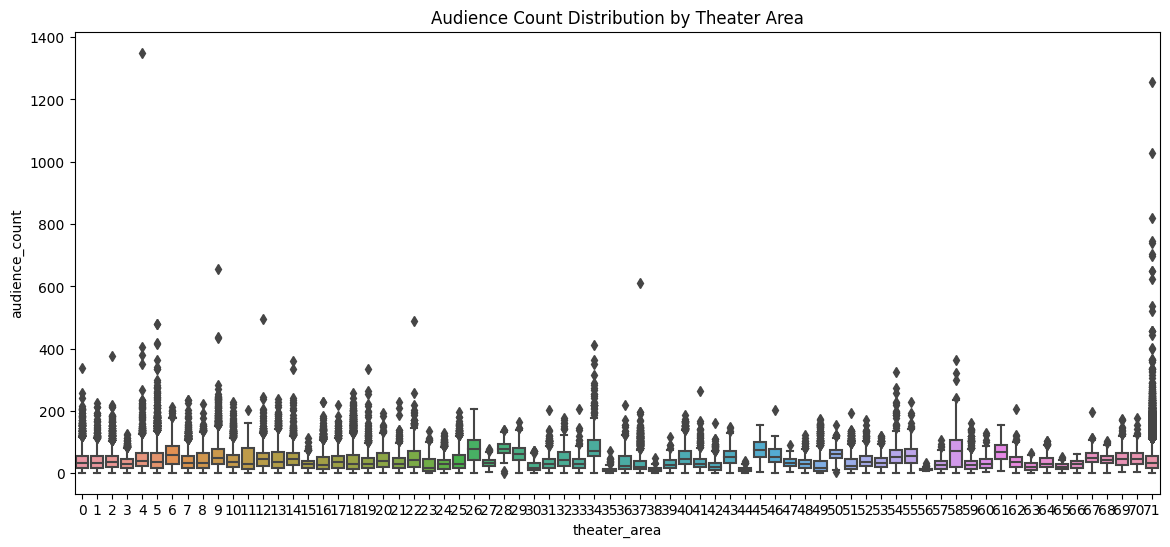

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.boxplot(x='theater_area', y='audience_count', data=main_df_eda)
plt.xticks()
plt.title("Audience Count Distribution by Theater Area")
plt.show()

Some areas are consistently high-demand (many large outliers), while others rarely fill up theaters. This suggests area is a strong predictor of audience size.

Average Audience Count by Theater Area 

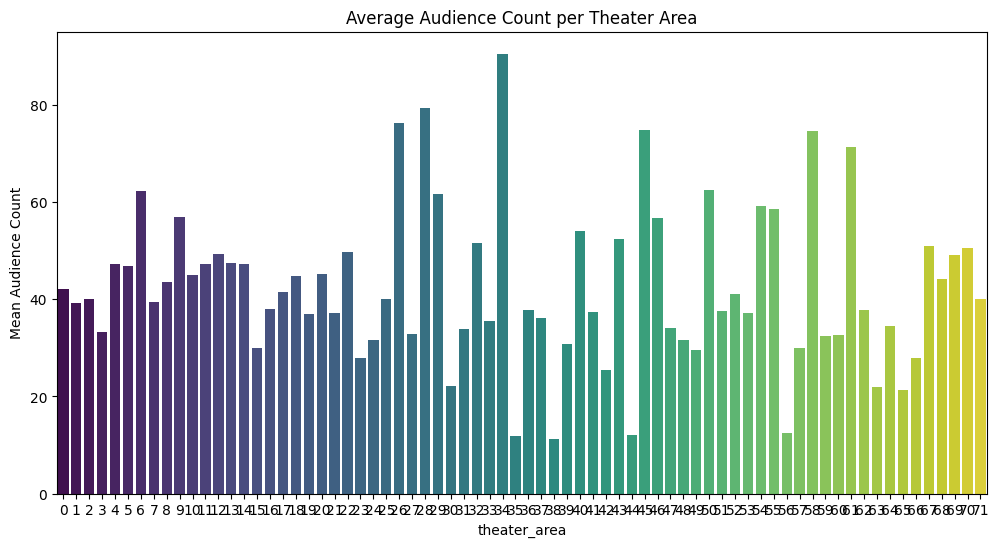

In [37]:
area_mean = main_df_eda.groupby('theater_area')['audience_count'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x= area_mean.index, y=area_mean.values, palette="viridis")
plt.xticks()
plt.title("Average Audience Count per Theater Area")
plt.ylabel("Mean Audience Count")
plt.show()

<Axes: >

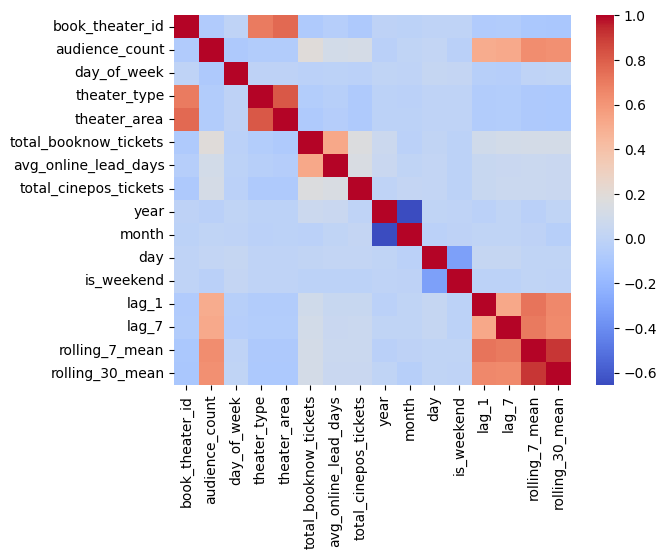

In [38]:
sns.heatmap(main_df_eda.corr(), annot=False, cmap="coolwarm")

We can observe positive correlation of our target feature (audience_count) with the interactive features we made. The correlation also confirms with positive correlation the relationship of theater features with the booking ids.

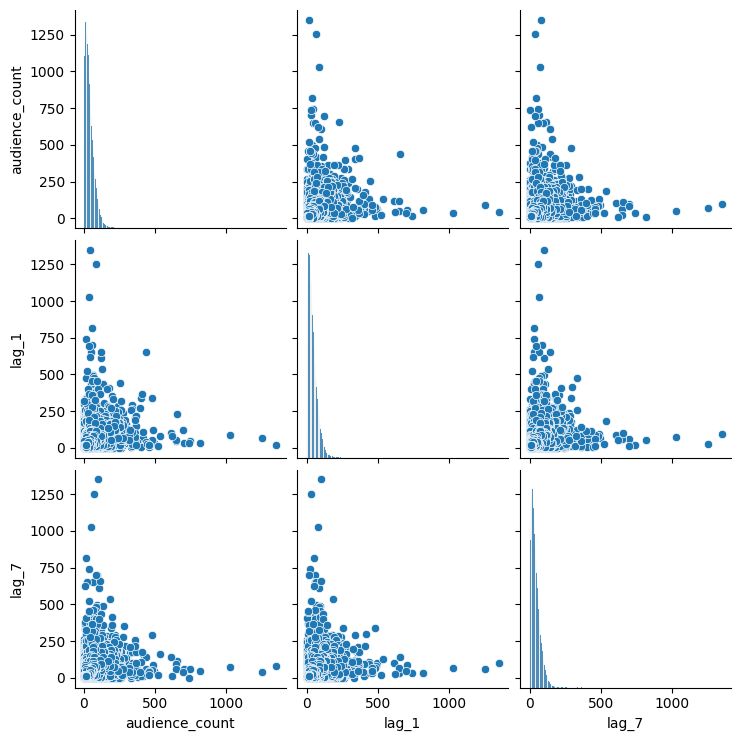

In [39]:
sns.pairplot(main_df_eda[['audience_count', 'lag_1', 'lag_7']])

Though not much , but audience_count increases when lag_1 and lag_7 values increase. This shows the right-skew nature with long tails suggesting outliers for some specific movies

In [40]:
print(main_df["show_date"].dt.day_name())

0            Friday
1          Saturday
2            Sunday
3            Monday
4         Wednesday
            ...    
214041       Friday
214042     Saturday
214043       Sunday
214044      Tuesday
214045    Wednesday
Name: show_date, Length: 214046, dtype: object


Since the days are mapped like this:

0 = Friday  
1 = Saturday  
2 = Sunday  
3 = Monday  
4 = Wednesday  
5 = Thursday  
6 = Tuesday



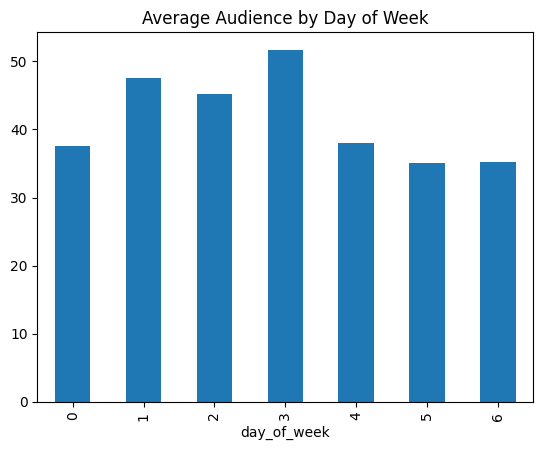

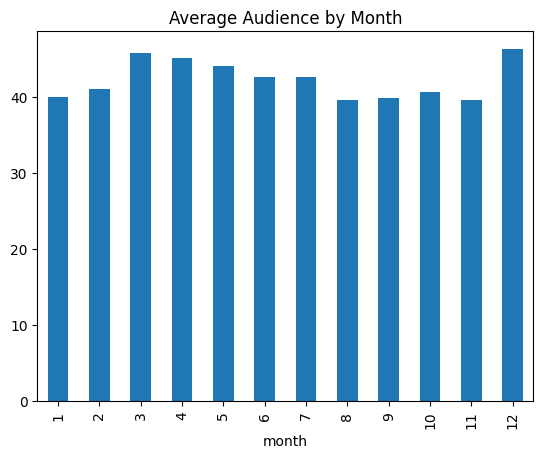

In [41]:
main_df_eda.groupby("day_of_week")["audience_count"].mean().plot(kind="bar")
plt.title("Average Audience by Day of Week")
plt.show()

main_df_eda.groupby("month")["audience_count"].mean().plot(kind="bar")
plt.title("Average Audience by Month")
plt.show()

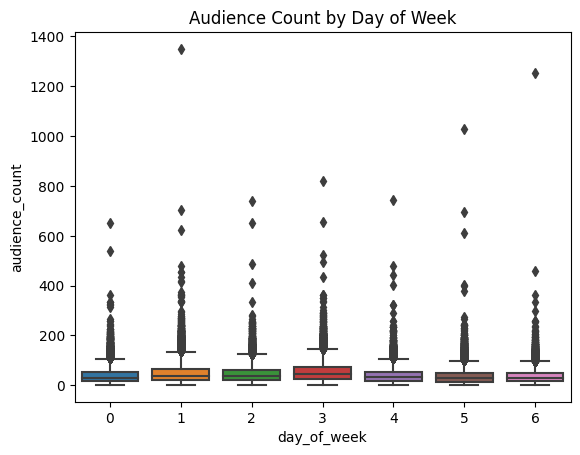

In [42]:
sns.boxplot(data=main_df_eda, x="day_of_week", y="audience_count")
plt.title("Audience Count by Day of Week")
plt.yticks()
plt.show()

Day of week has higher audience count for day 2 (sunday) suggesting that it is a holiday theaters observe a high audience count . 

Similarly we have high audience count for December suggesting that Christmas and winter may lead higher footfall of people in the theaters.

However, we have day 3 and March also with higher audience count

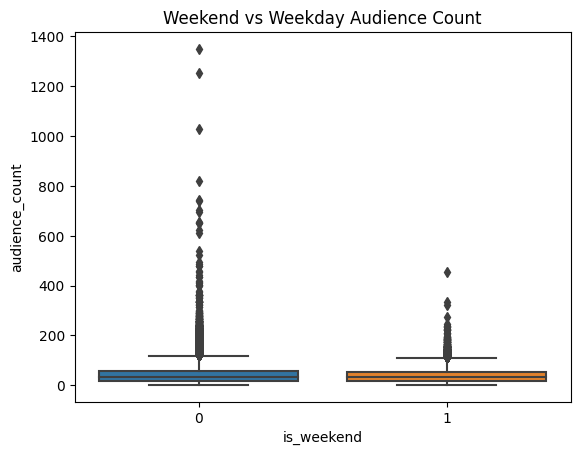

In [43]:
sns.boxplot(data=main_df_eda, x="is_weekend", y="audience_count")
plt.title("Weekend vs Weekday Audience Count")
plt.show()

Weekends do not show high audience count despite being holidays, this might suggest a weak relation with the target.

In [44]:
main_df_eda['theater_type'].value_counts()

theater_type
4    133896
3     44618
2     23203
1      6573
0      5756
Name: count, dtype: int64

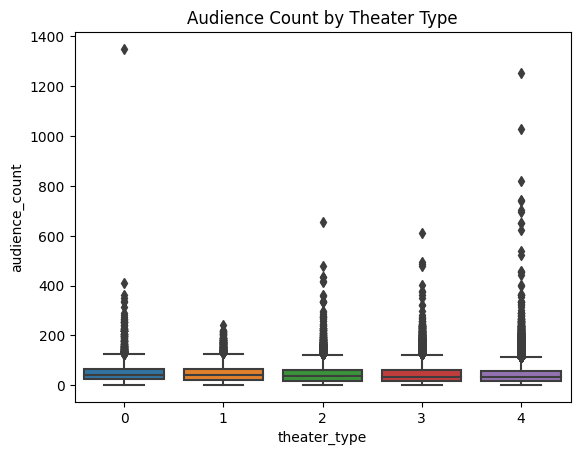

In [45]:
sns.boxplot(data=main_df_eda, x="theater_type", y="audience_count")
plt.title("Audience Count by Theater Type")
plt.show()

Type-4 theaters have high outliers, suggesting that it might be some multiplexes. Lower numbered theater type have smaller spread. 

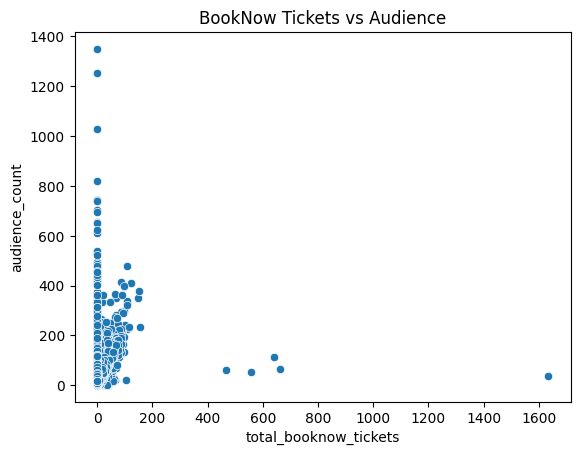

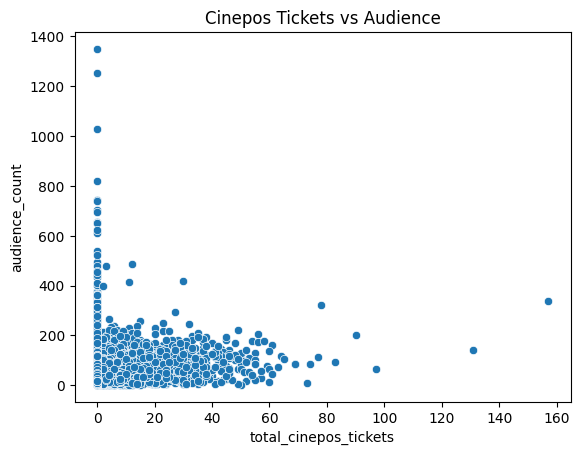

In [46]:
sns.scatterplot(data=main_df_eda, x="total_booknow_tickets", y="audience_count")
plt.title("BookNow Tickets vs Audience")
plt.show()

sns.scatterplot(data=main_df_eda, x="total_cinepos_tickets", y="audience_count")
plt.title("Cinepos Tickets vs Audience")
plt.show()

No linear relationship between booknow and audience_count
BookNow tickets show very weak correlation with audience count. Most shows have low booknow ticket numbers, even when actual audience is high. 

Audience increases cinepos tickets upto around total count of tickets 80. However, we see a high audience count for lower no. of tickets booked

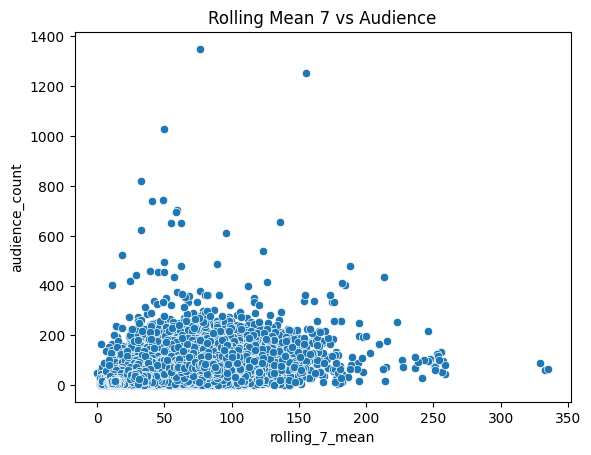

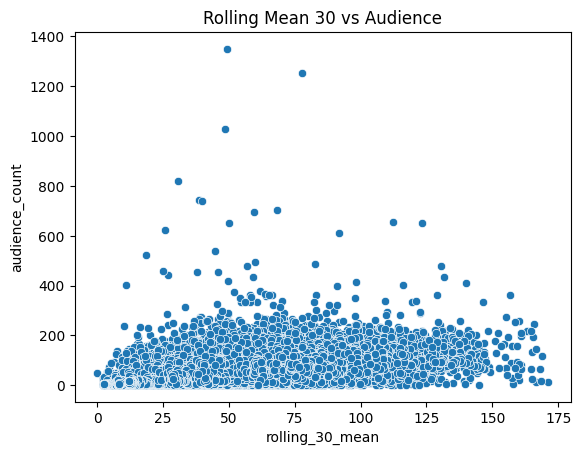

In [47]:
sns.scatterplot(data=main_df_eda, x="rolling_7_mean", y="audience_count")
plt.title("Rolling Mean 7 vs Audience")
plt.show()

sns.scatterplot(data=main_df_eda, x="rolling_30_mean", y="audience_count")
plt.title("Rolling Mean 30 vs Audience")
plt.show()

Rolling mean for 7 days with audience count have dense values for 0 to 200 rolling mean value . The audience count did increase slightly for a certain period.

Rolling mean for 30 days with audience count also have dense values for 0 to 200 rolling mean value but here the count is almost constant.

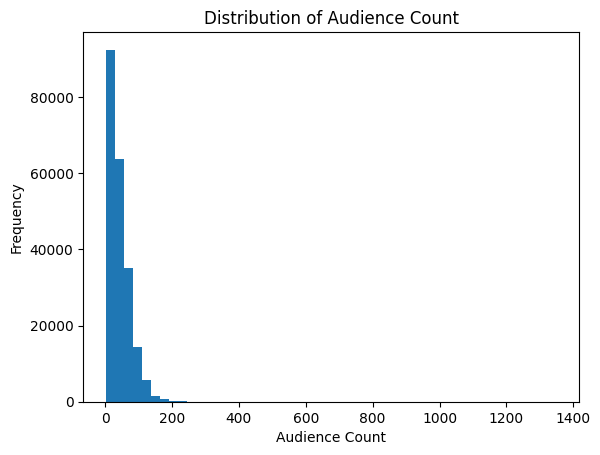

In [48]:
plt.hist(main_df_eda["audience_count"], bins=50)
plt.xlabel("Audience Count")
plt.ylabel("Frequency")
plt.title("Distribution of Audience Count")
plt.show()

The majority of the data is concentrated on the left side of the graph making it Right-Skew.
The distribution suggests consistency is on the lower side, but occasional hits drive significant spikes in attendance. 

# **Merge and Modify The Test Dataset**

In [49]:
sample_submission = pd.read_csv("/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")
test = sample_submission.copy()

# Split the submission file
test['show_date'] = test['ID'].apply(lambda x: x.rsplit('_', 1)[-1])
test['book_theater_id'] = test['ID'].apply(lambda x: x.rsplit('_', 1)[0])
test['show_date'] = pd.to_datetime(test['show_date'])
test.drop("audience_count", axis=1, inplace=True)

# Date Features on test
date_info['show_date'] = pd.to_datetime(date_info['show_date'])

test = pd.merge(test, date_info, on=['show_date'], how='left')
test["year"] = test["show_date"].dt.year
test["month"] = test["show_date"].dt.month
test["day"] = test["show_date"].dt.day
test["is_weekend"] = test["day"].isin([5, 6]).astype(int)


# Theater info Features on test

test = pd.merge(test, booknow_theaters, on=['book_theater_id'], how='left')
test['theater_type'] = test['theater_type'].fillna('Unknown')
test['theater_area'] = test['theater_area'].fillna('Unknown')


# Booking features

test = pd.merge(test, booknow_agg, on=["book_theater_id", "show_date"], how='left')
test = pd.merge(test, cinepos_agg, on=["book_theater_id", "show_date"], how='left')

test[["total_booknow_tickets", "total_cinepos_tickets", "avg_online_lead_days"]] = \
    test[["total_booknow_tickets", "total_cinepos_tickets", "avg_online_lead_days"]].fillna(0)


**Make the Interactive features**

In [50]:
last = main_df.groupby("book_theater_id").agg(
    lag_1=("lag_1","last"),
    lag_7=("lag_7","last"),
    rolling_7_mean=("rolling_7_mean","last"),
    rolling_30_mean=("rolling_30_mean","last")
).reset_index()

test = test.merge(last, on="book_theater_id", how="left")
test.fillna(0, inplace=True)

In [51]:
test.head()

,ID,show_date,book_theater_id,day_of_week,year,month,day,is_weekend,theater_type,theater_area,latitude,longitude,index,total_booknow_tickets,avg_online_lead_days,total_cinepos_tickets,lag_1,lag_7,rolling_7_mean,rolling_30_mean
0,book_00001_2024-03-01,2024-03-01,book_00001,Friday,2024,3,1,0,Drama,Area_002,23.00441,79.934515,0.0,0.0,0.0,0.0,16.0,14.0,37.714286,37.933333
1,book_00001_2024-03-02,2024-03-02,book_00001,Saturday,2024,3,2,0,Drama,Area_002,23.00441,79.934515,0.0,0.0,0.0,0.0,16.0,14.0,37.714286,37.933333
2,book_00001_2024-03-03,2024-03-03,book_00001,Sunday,2024,3,3,0,Drama,Area_002,23.00441,79.934515,0.0,0.0,0.0,0.0,16.0,14.0,37.714286,37.933333
3,book_00001_2024-03-04,2024-03-04,book_00001,Monday,2024,3,4,0,Drama,Area_002,23.00441,79.934515,0.0,0.0,0.0,0.0,16.0,14.0,37.714286,37.933333
4,book_00001_2024-03-06,2024-03-06,book_00001,Wednesday,2024,3,6,1,Drama,Area_002,23.00441,79.934515,0.0,0.0,0.0,0.0,16.0,14.0,37.714286,37.933333


**Transforming Categorical Features**

In [52]:
#Encode test using same mapping as train


# test_df['book_theater_id'] = test_df['book_theater_id'].astype(str)

for col in cat_cols:
    le = encoders[col]

    # Create mapping from train/val encoder classes
    mapping = {label: i for i, label in enumerate(le.classes_)}

    # Map test categories → unseen become -1
    test[col] = test[col].map(mapping).fillna(-1).astype(int)


# **Final Features to consider**

**Train Data**

In [53]:
features = [col for col in train_df.columns if col not in ['audience_count']]

X_train = train_df[features]
y_train = train_df['audience_count']

X_val = val_df[features]
y_val = val_df['audience_count']

X = pd.concat([X_train , X_val])
y = pd.concat([y_train , y_val])

**Test Data**

In [54]:
test.head()

,ID,show_date,book_theater_id,day_of_week,year,month,day,is_weekend,theater_type,theater_area,latitude,longitude,index,total_booknow_tickets,avg_online_lead_days,total_cinepos_tickets,lag_1,lag_7,rolling_7_mean,rolling_30_mean
0,book_00001_2024-03-01,2024-03-01,0,0,2024,3,1,0,2,1,23.00441,79.934515,0.0,0.0,0.0,0.0,16.0,14.0,37.714286,37.933333
1,book_00001_2024-03-02,2024-03-02,0,2,2024,3,2,0,2,1,23.00441,79.934515,0.0,0.0,0.0,0.0,16.0,14.0,37.714286,37.933333
2,book_00001_2024-03-03,2024-03-03,0,3,2024,3,3,0,2,1,23.00441,79.934515,0.0,0.0,0.0,0.0,16.0,14.0,37.714286,37.933333
3,book_00001_2024-03-04,2024-03-04,0,1,2024,3,4,0,2,1,23.00441,79.934515,0.0,0.0,0.0,0.0,16.0,14.0,37.714286,37.933333
4,book_00001_2024-03-06,2024-03-06,0,6,2024,3,6,1,2,1,23.00441,79.934515,0.0,0.0,0.0,0.0,16.0,14.0,37.714286,37.933333


In [55]:
X_test = test[features] 

# **Light GBM**

In [56]:
lgbm = LGBMRegressor(
    num_leaves=127,
    learning_rate=0.03,
    n_estimators=1500,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_lambda=5,
    max_depth=-1
)

lgbm.fit(X_train, y_train)

y_val_pred = lgbm.predict(X_val)

score = r2_score(y_val, y_val_pred)

print(" Validation R2Score:", score)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010850 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1598
[LightGBM] [Info] Number of data points in the train set: 172253, number of used features: 14
[LightGBM] [Info] Start training from score 41.839562
 Validation R2Score: 0.5221308874343584


# **Random Forest Regressor**

Validation R2_score: 0.49399271647562937


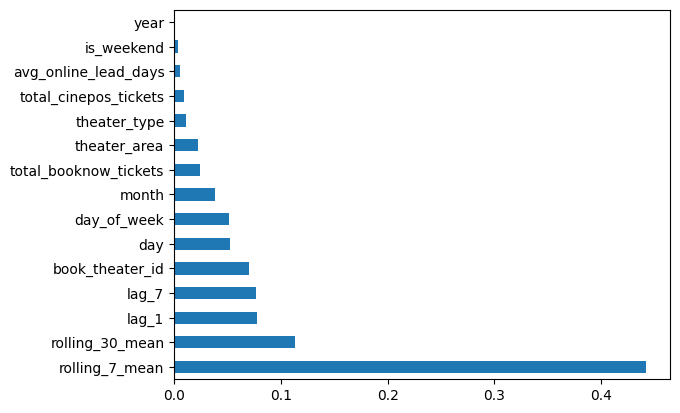

In [57]:
rf = RandomForestRegressor(
    n_estimators=300,      # number of trees
    max_depth=None,        # let trees grow fully (can tune)
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


y_pred = rf.predict(X_val)

score = r2_score(y_val, y_pred)

print("Validation R2_score:", score)

feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.show()

# **XGB**

In [58]:
xgb = XGBRegressor(
        objective="reg:squarederror",
        learning_rate=0.05,
        max_depth=6,
        n_estimators=1000,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
    
# Fit
xgb.fit(X_train, y_train)
    
# Predict
y_pred = xgb.predict(X_val)

score = r2_score(y_val, y_pred)

print(f"R2_score : {score:.5f}")

R2_score : 0.51754


# **Hyperparameter Tuning with Randomized SearchCV**

**Light GBM**

In [59]:
# lgbm_final_model = LGBMRegressor(
#     n_estimators=5000,
#     learning_rate=0.01,
#     num_leaves=64,
#     max_depth=-1,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42
# )

# lgbm_final_model.fit(X_train, y_train)


# lgbm = LGBMRegressor(
#     objective='regression',
#     random_state=42
# )


# param_dist = {
#     'num_leaves': [31, 63, 95, 127, 150, 200],
#     'min_child_samples': [20, 30, 40, 50, 70, 90],
#     'learning_rate': [0.005, 0.01, 0.015, 0.02],
#     'n_estimators': [1500, 2000, 2500, 3000, 4000],
#     'subsample': [0.7, 0.8, 0.9, 1.0],
#     'colsample_bytree': [0.7, 0.8, 0.85, 0.9],
#     'reg_lambda': [0.0, 1.0, 2.0, 5.0],
#     'reg_alpha': [0.0, 0.5, 1.0, 2.0],
#     'max_depth': [-1, 10, 12, 14]
# }

# random_search_1 = RandomizedSearchCV(
#     estimator=lgbm,
#     param_distributions=param_dist,
#     n_iter=30,                    
#     scoring='r2',
#     verbose=1,
#     n_jobs=-1,
#     random_state=42
# )

# random_search_1.fit(X_train, y_train)

# print("Best Score:", random_search_1.best_score_)
# print("Best Params:", random_search_1.best_params_)

# lgbm_final_model = random_search_1.best_estimator_

# # Validation performance


# lgbm_final_model.fit(X_train, y_train)

# y_pred_lgbm = lgbm_final_model.predict(X_val)

# score_lgbm = r2_score(y_val, y_pred_lgbm)

# best_model_1 = lgbm_final_model

**Random Forest with RandomizedSearchCV**

In [60]:
# # Defining RandomForest Regressor

# rf = RandomForestRegressor()

# # Giving the required list of parameters to be taken

# param_dist = {
#     'n_estimators': [200, 500, 800],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['sqrt', 'log2']
# }

# # Defining the random search

# random_search_2 = RandomizedSearchCV(
#     rf,
#     param_distributions=param_dist,
#     n_iter=20,
#     cv=3,
#     scoring='neg_root_mean_squared_error',
#     verbose=1,
#     n_jobs=-1,
#     random_state=42
# )

# # Training the dataset on the random search of Random Foreset Regressor

# random_search_2.fit(X_train, y_train)

# # Looking for the model with best parameters

# rf_final_model = random_search_2.best_estimator_

# rf_final_model.fit(X_train,y_train)

# y_pred_rf = rf_final_model.predict(X_val)

# score_rf = r2_score(y_val, y_pred_rf)

**XGB with Randomised Search CV**

In [61]:
# Defining the XGB Regressor

xgb = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

# Parameter search space
params = {
    'n_estimators': randint(200, 2000),
    "learning_rate": uniform(0.01, 0.3),    # 0.01–0.11
    "max_depth": randint(3, 10),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.6, 0.4),         # 0.6–1.0
    "colsample_bytree": uniform(0.6, 0.4),  # 0.6–1.0
    "reg_alpha": uniform(0, 1),             # L1 regularization
    "reg_lambda": uniform(0.5, 2.0)         # L2 regularization
}

# Randomized search

random_search_3 = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter=30,   # number of random combos to try
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit

random_search_3.fit(X_train, y_train)


# Looking for the model with best parameters

xgb_final_model = random_search_3.best_estimator_


xgb_final_model.fit(X_train,y_train)

y_pred_xgb = xgb_final_model.predict(X_val)

score_xgb = r2_score(y_val, y_pred_xgb)

best_model_1 = xgb_final_model

Fitting 3 folds for each of 30 candidates, totalling 90 fits


# **Selecting the "Best Model"**

In [62]:
# results = {'score_lgbm' : score_lgbm,
#           'score_rf': score_rf,
#           'score_xgb': score_xgb}

# print(results)
  
# best_model_name = max(results, key=results.get)

# best_model_1 = models[best_model_name]

# print("The Best Model found is ", best_model_1)

In [63]:
# models = {
#     "LightGBM": lgbm_final_model,
#     "XGBoost": xgb_final_model,
#     "Random Forest": rf_final_model
# }

# results = {}
# from sklearn.metrics import r2_score

# for name,model in models.items():
#     model.fit(X_train,y_train)
#     y_pred = model.predict(X_val)
#     score = r2_score(y_val, y_pred)
#     results[name] = score
#     print(f"{name} Validation R2_score: {score:.4f}")


# best_model_name = min(results, key=results.get)


# best_model_1 = models[best_model_name]

# print("The Best Model found is ", best_model_1)

# **Prediction**

In [64]:
final_pred =best_model_1.predict(X_test)

final_pred[final_pred<0] = 0

final_pred = np.round(final_pred).astype(int)

sample_submission  = test[['ID']].copy()
sample_submission['audience_count'] = final_pred
sample_submission[['ID', 'audience_count']].to_csv('submission.csv', index=False)


print("submission_lgbm.csv")

submission_lgbm.csv


# **Dummy Regressor**

In [65]:
# import numpy as np
# import pandas as pd
# from sklearn.dummy import DummyRegressor

# # ------------------------------
# # 1. Load Data
# # ------------------------------
# train= train_df.copy()

# sample_submission = pd.read_csv("//kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv")

# # ------------------------------
# # 2. Target
# # ------------------------------
# target = "audience_count"
# y = train[target]

# # ------------------------------
# # 3. Fit Dummy Regressor
# # ------------------------------
# # Strategy options: "mean", "median", "quantile", "constant"
# dummy = DummyRegressor(strategy="mean")
# dummy.fit(np.zeros((len(y), 1)), y)   # dummy regressor ignores features

# # ----------------------------

# y_pred = dummy.predict(np.zeros((len(sample_submission), 1)))

# # ------------------------------
# # 5. Create Submission
# # ------------------------------
# submission = sample_submission.copy()
# submission[target] = y_pred
# submission.to_csv("submission.csv", index=False)

# print("Submission file created with shape:", submission.shape)
# print(submission.head())

